In [2]:
# === Utilities: robust answer extraction from various LLM payload shapes ===
from typing import Any, Dict, List, Union
import json
import re

def _strip_code_fences(text: str) -> str:
    if text is None:
        return ""
    # Remove common code-fence wrappers like ```json ... ```
    text = text.strip()
    fence = re.compile(r"^```[a-zA-Z0-9_-]*\s*([\s\S]*?)\s*```$", re.MULTILINE)
    m = fence.match(text)
    if m:
        return m.group(1).strip()
    return text

def _maybe_load_json(text: str):
    if not isinstance(text, str):
        return None
    try:
        return json.loads(_strip_code_fences(text))
    except Exception:
        return None

def _collect_text_candidates_from_dict(d: Dict[str, Any]) -> List[str]:
    cands: List[str] = []

    # OpenAI Chat Completions (legacy & current)
    try:
        cands.append(d["choices"][0]["message"]["content"])
    except Exception:
        pass

    # OpenAI Responses API (2024+): convenience field
    try:
        cands.append(d["output_text"])
    except Exception:
        pass

    # OpenAI Responses API: streaming-style aggregated output
    try:
        out = d.get("output", [])
        if isinstance(out, list):
            cands.extend([x.get("content", "") if isinstance(x, dict) else "" for x in out])
    except Exception:
        pass

    # Anthropic: content as list of blocks [{"type":"text","text":"..."}]
    try:
        content = d.get("content")
        if isinstance(content, list):
            for b in content:
                if isinstance(b, dict):
                    # Claude v3 format
                    if b.get("type") == "text" and isinstance(b.get("text"), str):
                        cands.append(b["text"])
                    # Older "tool_use" etc. ignored
        # Older Anthropic "completion" field
        if isinstance(d.get("completion"), str):
            cands.append(d["completion"])
    except Exception:
        pass

    # Mistral-like
    try:
        cands.append(d["choices"][0]["message"]["content"])
    except Exception:
        pass

    # Generic fields commonly used
    for key in ["answer", "final", "final_answer", "result", "response", "text"]:
        v = d.get(key)
        if isinstance(v, str):
            cands.append(v)

    # Tool call results often embed the text
    try:
        tool_calls = d["choices"][0]["message"].get("tool_calls", [])
        for t in tool_calls:
            fargs = t.get("function", {}).get("arguments", "")
            loaded = _maybe_load_json(fargs)
            if isinstance(loaded, dict):
                for k in ["answer", "final", "response", "text"]:
                    vv = loaded.get(k)
                    if isinstance(vv, str):
                        cands.append(vv)
    except Exception:
        pass

    # If there are nested candidates in a "data" envelope
    try:
        data = d.get("data")
        if isinstance(data, dict):
            nested = _collect_text_candidates_from_dict(data)
            cands.extend(nested)
    except Exception:
        pass

    # Deduplicate while keeping order
    seen = set()
    result = []
    for x in cands:
        if isinstance(x, str):
            xx = x.strip()
            if xx and xx not in seen:
                result.append(xx)
                seen.add(xx)
    return result

def extract_model_answer(payload: Any) -> str:
    """
    Extract the assistant's final answer text from a variety of payloads.
    Supports:
      - OpenAI Chat Completions, Responses API
      - Anthropic Claude (content blocks or completion)
      - Mistral-style outputs
      - Generic dicts: keys like 'answer'/'final'/'text'
      - JSON strings and fenced JSON strings
      - Strings that contain 'Final Answer:' prefix
    Returns "" if nothing can be extracted.
    """
    candidates: List[str] = []

    # If it's a string, try JSON first; otherwise treat as final text
    if isinstance(payload, str):
        loaded = _maybe_load_json(payload)
        if isinstance(loaded, dict):
            candidates.extend(_collect_text_candidates_from_dict(loaded))
        else:
            candidates.append(payload.strip())
    elif isinstance(payload, dict):
        candidates.extend(_collect_text_candidates_from_dict(payload))
    elif isinstance(payload, list):
        # Sometimes responses are arrays of segments
        for item in payload:
            if isinstance(item, (dict, list, str)):
                ans = extract_model_answer(item)
                if ans:
                    candidates.append(ans)

    # Heuristics: look for "Final Answer:" marker
    expanded: List[str] = []
    for c in candidates:
        # Split on common markers
        parts = re.split(r"(?i)final\s*answer\s*:\s*", c)
        if len(parts) > 1:
            expanded.append(parts[-1].strip())
        else:
            expanded.append(c.strip())

    # Remove leftover code fences and role prefixes
    cleaned = [re.sub(r"^(assistant|model)\s*:\s*", "", _strip_code_fences(x)).strip()
               for x in expanded if isinstance(x, str)]

    # Pick the last non-empty as the final (typical pattern: reasoning then answer)
    for candidate in reversed(cleaned):
        if candidate:
            return candidate

    return ""

def extract_all_candidates(payload: Any) -> List[str]:
    """
    Return *all* candidate answer strings found in the payload, after cleaning.
    Useful for debugging and audits.
    """
    if isinstance(payload, str):
        loaded = _maybe_load_json(payload)
        if isinstance(loaded, dict):
            cands = _collect_text_candidates_from_dict(loaded)
        else:
            cands = [payload]
    elif isinstance(payload, dict):
        cands = _collect_text_candidates_from_dict(payload)
    elif isinstance(payload, list):
        cands = []
        for item in payload:
            ans = extract_model_answer(item)
            if ans:
                cands.append(ans)
    else:
        cands = []

    out = []
    for c in cands:
        c = _strip_code_fences(c)
        c = re.sub(r"(?i)^final\s*answer\s*:\s*", "", c).strip()
        if c:
            out.append(c)
    # Dedup while preserving order
    seen = set()
    res = []
    for x in out:
        if x not in seen:
            res.append(x)
            seen.add(x)
    return res


# Math Problem Performance Test

This notebook tests the model on problems from problems.csv and analyzes performance by problem type and difficulty.

In [3]:
import os

repo_path = 'probing-llm-math'
if not os.path.exists(repo_path):
    !git clone --branch performance-test https://github.com/1hamzaiqbal/probing-llm-math.git
else:
    print(f"Repository '{repo_path}' already exists.")

Cloning into 'probing-llm-math'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 56 (delta 16), reused 43 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 656.52 KiB | 14.27 MiB/s, done.
Resolving deltas: 100% (16/16), done.


## Setup and Model Loading

In [4]:
!pip install -q transformers accelerate pandas seaborn matplotlib tqdm
import torch
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

# === Display configuration: show full text in DataFrames/prints ===
pd.set_option("display.max_colwidth", None)   # don't truncate long strings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [5]:


# Load model and tokenizer
model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
print(f"Loading model: {model_name}...")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    dtype=torch.float16
)

print("✅ Model loaded successfully!")

Loading model: deepseek-ai/DeepSeek-R1-Distill-Qwen-7B...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/680 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00002-of-000002.safetensors:   0%|          | 0.00/6.62G [00:00<?, ?B/s]

model-00001-of-000002.safetensors:   0%|          | 0.00/8.61G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

✅ Model loaded successfully!


## Load Problems Dataset

In [6]:
# Load problems from CSV
df = pd.read_csv('/content/probing-llm-math/data/problems.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nTopics: {df['topic'].unique()}")
print(f"\nDifficulty levels: {df['difficulty'].unique()}")
print(f"\nProblems per topic-difficulty combination:")
print(df.groupby(['topic', 'difficulty']).size())

# Display first few problems
print("\nFirst few problems:")
df.head()

Dataset shape: (75, 5)

Columns: ['id', 'topic', 'difficulty', 'question', 'answer']

Topics: ['Algebra' 'Number Theory' 'Counting & Probability']

Difficulty levels: ['Level 1' 'Level 2' 'Level 3' 'Level 4' 'Level 5']

Problems per topic-difficulty combination:
topic                   difficulty
Algebra                 Level 1       5
                        Level 2       5
                        Level 3       5
                        Level 4       5
                        Level 5       5
Counting & Probability  Level 1       5
                        Level 2       5
                        Level 3       5
                        Level 4       5
                        Level 5       5
Number Theory           Level 1       5
                        Level 2       5
                        Level 3       5
                        Level 4       5
                        Level 5       5
dtype: int64

First few problems:


,id,topic,difficulty,question,answer
0,1,Algebra,Level 1,"If $x = 2$ and $y = 5$, then what is the value of $\frac{x^4+2y^2}{6}$ ?",We have \[\frac{x^4 + 2y^2}{6} = \frac{2^4 + 2(5^2)}{6} = \frac{16+2(25)}{6} = \frac{16+50}{6} = \frac{66}{6} = \boxed{11}.\]
1,2,Algebra,Level 1,"The perimeter of a rectangular garden is 60 feet. If the length of the field is twice the width, what is the area of the field, in square feet?","If the length is $l$ and the width is $w$, then the perimeter is $2l+2w$. We can set up the equations $2l+2w=60 \Rightarrow l+w=30$ and $l=2w$. Now we substitute $l$ in terms of $w$ into the first equation and get $l+w=2w+w=30$, so $w=10$ and $l=2(10)=20$. That means the area of the rectangular garden is $lw=20(10)=\boxed{200}$ square feet."
2,3,Algebra,Level 1,The function $f(x)$ is defined by $f(x)=x^{2}-x$. What is the value of $f(4)$?,$f(4)=4^2-4=16-4=\boxed{12}$.
3,4,Algebra,Level 1,The sum of two numbers is $45$. Their difference is $3$. What is the lesser of the two numbers?,"Let $x,y$ be the larger and smaller numbers, respectively. We have $x+y=45$ and $x-y=3$. Thus: $y=\frac{1}{2}((x+y)-(x-y))=\frac{1}{2}(45-3)=\boxed{21}$."
4,5,Algebra,Level 1,What is the value of $(2x + 5)^2$ when $x = 3$?,We have $(2x+5)^2 = (2\cdot 3 + 5)^2 = 11^2 = \boxed{121}$.


## Helper Functions

In [7]:
def extract_boxed_answer(text):
    """Extract answer from \\boxed{} format in solution text"""
    if text is None:
        return None
    match = re.search(r'\\boxed\{([^}]+)\}', text)
    return match.group(1) if match else None

def generate_answer(question, max_new_tokens=512, return_hidden_states=False):
    """
    Generate model answer for a given question, optionally returning hidden states.
    The prompt explicitly asks the model to put the final answer in \boxed{...}
    on its own line so downstream matching is easy/reliable.
    """
    prompt = (
        "Solve the following math problem step by step. "
        "At the very end, output one final line of the form: Final: \\boxed{the numeric result}.\n\n"
        f"{question}\n\n"
        "Solution:"
    )

    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = inputs.to(model.device)

    with torch.inference_mode():
        if return_hidden_states:
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
                output_hidden_states=True,
                return_dict_in_generate=True,
            )
            generated_ids = outputs.sequences
            text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
            return text, outputs.hidden_states
        else:
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
            text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
            return text


import re
from fractions import Fraction

def _normalize_ans_text(s: str):
    if s is None:
        return None
    s = s.strip()
    # LaTeX cleanups
    s = s.replace("\\,", "").replace("$", "")
    s = s.replace("\\left", "").replace("\\right", "")
    s = s.replace("\\dfrac", "\\frac")
    # remove \text{...} units and any braces they introduce
    s = re.sub(r"\\text\{[^}]*\}", "", s)
    # unwrap boxed
    s = re.sub(r"\\boxed\{([^}]*)\}", r"\1", s)
    # collapse spaces
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _to_fraction(val: str):
    if val is None:
        return None
    v = val.strip().replace(" ", "").replace(",", "")
    # mixed number like "1 1/2"
    m = re.match(r"^(-?\d+)\s+(\d+)/(\d+)$", val.strip())
    if m:
        whole, num, den = m.groups()
        return Fraction(int(whole)) + Fraction(int(num), int(den))
    # a/b fraction
    if re.match(r"^-?\d+/-?\d+$", v):
        num, den = v.split("/")
        return Fraction(int(num), int(den))
    # integer or decimal
    try:
        return Fraction(v)
    except Exception:
        # last resort: pull first numeric token
        m2 = re.search(r"-?\d+(?:/\d+|\.\d+)?", v)
        if m2:
            try:
                return Fraction(m2.group(0))
            except Exception:
                return None
        return None

def _extract_candidates(text: str):
    if not text:
        return []
    cands = []
    # prefer boxed candidates
    cands += re.findall(r"\\boxed\{([^}]*)\}", text or "")
    # common fractions like a/b
    cands += re.findall(r"(?<![\d/])-?\d+\s*/\s*-?\d+(?![\d/])", text or "")
    # integers/decimals
    cands += re.findall(r"(?<![\d.])-?\d+(?:\.\d+)?(?![\d.])", text or "")
    # unique, preserve order
    out, seen = [], set()
    for c in (x.strip() for x in cands if x.strip()):
        k = c.replace(" ", "")
        if k not in seen:
            seen.add(k)
            out.append(c)
    return out

def check_answer_match(model_answer, correct_answer_text):
    """Robust numeric/boxed matcher."""
    if correct_answer_text is None:
        return False

    gold_in_box = extract_boxed_answer(correct_answer_text)
    gold = _normalize_ans_text(gold_in_box) if gold_in_box else _normalize_ans_text(correct_answer_text)
    if not gold:
        return False

    gold_frac = _to_fraction(gold)

    # 1) direct boxed equality if present
    model_boxed = extract_boxed_answer(model_answer or "")
    if model_boxed and _normalize_ans_text(model_boxed) == gold:
        return True

    # 2) numeric candidates equivalence
    for cand in _extract_candidates(model_answer or ""):
        cn = _normalize_ans_text(cand)
        if cn == gold:
            return True
        if gold_frac is not None:
            cf = _to_fraction(cn)
            if cf is not None and cf == gold_frac:
                return True

    # 3) last fallback: substring of normalized gold
    return _normalize_ans_text(model_answer or "").find(gold) != -1


print("✅ Helper functions defined")

✅ Helper functions defined


## Smoke test

In [8]:
# ===== Single-question smoke test: raw vs edited (with evaluation) =====
import os, re, time
import pandas as pd
from fractions import Fraction

# ---------- Config ----------
CSV_PATH_CANDIDATES = [
    "/content/probing-llm-math/data/problems.csv",
    "probing-llm-math/data/problems.csv",
    "data/problems.csv",
    "problems.csv",
]
# Select one problem (prefer easy Algebra; else first row)
PREF_TOPIC = "Algebra"
PREF_DIFFICULTY_CONTAINS = "1"
MAX_NEW_TOKENS = 256  # keep quick but not too short

# ---------- Small helpers (robust, no deps on your other cells) ----------
def extract_boxed_answer(text: str):
    if not isinstance(text, str):
        return None
    m = re.search(r'\\boxed\{([^}]*)\}', text)
    return m.group(1).strip() if m else None

def _normalize_ans_text(s: str):
    if s is None:
        return None
    s = s.strip()
    s = s.replace("\\,", "").replace("$", "").replace("\\left", "").replace("\\right", "")
    s = re.sub(r"\\boxed\{([^}]*)\}", r"\1", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _to_fraction(val: str):
    if val is None:
        return None
    v = val.strip().replace(" ", "").replace(",", "")
    m = re.match(r"^(-?\d+)\s+(\d+)/(\d+)$", val.strip())  # mixed number e.g. 1 1/2
    if m:
        whole, num, den = m.groups()
        return Fraction(int(whole)) + Fraction(int(num), int(den))
    if re.match(r"^-?\d+/-?\d+$", v):  # a/b
        num, den = v.split("/")
        return Fraction(int(num), int(den))
    try:
        return Fraction(v)  # int or decimal -> fraction
    except Exception:
        m2 = re.search(r"-?\d+(?:/\d+|\.\d+)?", v)
        if m2:
            try:
                return Fraction(m2.group(0))
            except Exception:
                return None
        return None

def _extract_candidate_numbers(text: str):
    if not text:
        return []
    # priority: boxed, then fractions, then numbers/decimals
    cands = []
    cands += re.findall(r"\\boxed\{([^}]*)\}", text)
    cands += re.findall(r"(?<![\d/])-?\d+\s*/\s*-?\d+(?![\d/])", text)
    cands += re.findall(r"(?<![\d.])-?\d+(?:\.\d+)?(?![\d.])", text)
    out, seen = [], set()
    for c in [x.strip() for x in cands if x.strip()]:
        key = c.replace(" ", "")
        if key not in seen:
            seen.add(key)
            out.append(c)
    return out

def check_answer_match(model_text: str, gold_text: str) -> bool:
    if gold_text is None:
        return False
    gold_box = extract_boxed_answer(gold_text)
    gold = _normalize_ans_text(gold_box) if gold_box else _normalize_ans_text(gold_text)
    if not gold:
        return False

    gold_frac = _to_fraction(gold)
    # try boxed first
    model_box = extract_boxed_answer(model_text or "")
    if model_box and _normalize_ans_text(model_box) == gold:
        return True

    # try numeric candidates
    for cand in _extract_candidate_numbers(model_text or ""):
        cn = _normalize_ans_text(cand)
        if cn == gold:
            return True
        if gold_frac is not None:
            cf = _to_fraction(cn)
            if cf is not None and cf == gold_frac:
                return True

    # fallback: substring
    return gold in (model_text or "")

def postprocess_to_boxed(model_text: str):
    """If no boxed final is present, try to add one from the last numeric candidate."""
    if not model_text:
        return model_text, None
    if extract_boxed_answer(model_text):
        return model_text, extract_boxed_answer(model_text)

    cands = _extract_candidate_numbers(model_text)
    last = cands[-1] if cands else None
    if last:
        edited = model_text.rstrip() + f"\nFinal: \\boxed{{{last}}}"
        return edited, last
    return model_text, None

# ---------- Load one problem ----------
if 'df' in globals() and isinstance(df, pd.DataFrame):
    _df = df
else:
    _df = None
    for p in CSV_PATH_CANDIDATES:
        if os.path.exists(p):
            _df = pd.read_csv(p)
            print(f"Loaded CSV: {p} | shape: {_df.shape}")
            break
    if _df is None:
        raise FileNotFoundError("Could not find problems.csv; set df or update CSV_PATH_CANDIDATES.")

sel = _df[
    (_df['topic'] == PREF_TOPIC) &
    (_df['difficulty'].astype(str).str.contains(PREF_DIFFICULTY_CONTAINS, regex=False))
]
row = (sel.iloc[0] if len(sel) else _df.iloc[0])

qid = row.get('id', 'NA')
question = row['question']
gold = extract_model_answer(row)
topic = row.get('topic','NA')
diff = row.get('difficulty','NA')

print("="*100)
print(f"Problem ID: {qid} | {topic} / {diff}")
print("QUESTION:\n", question)
print("TARGET (boxed if present):", extract_boxed_answer(gold))
print("="*100)

# ---------- Generate once (use existing generate_answer if available) ----------
def _gen_once(q: str, max_new_tokens: int = MAX_NEW_TOKENS):
    if 'generate_answer' in globals():
        return generate_answer(q, max_new_tokens=max_new_tokens)  # your function
    # minimal local fallback (greedy, no sampling)
    prompt = (
        "Solve the following math problem step by step. "
        "At the very end, output one final line of the form: Final: \\boxed{your answer}.\n\n"
        f"{q}\n\n"
        "Solution:"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.inference_mode():
        ids = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(ids[0], skip_special_tokens=True)

t0 = time.time()
raw_out = _gen_once(question, MAX_NEW_TOKENS)
dt = time.time() - t0

edited_out, edited_pick = postprocess_to_boxed(raw_out)

# ---------- Evaluate raw + edited ----------
raw_ok = check_answer_match(raw_out, gold)
edited_ok = check_answer_match(edited_out, gold)

print(f"\n⏱️ Generation time: {dt:.2f}s")
print("\n--- RAW OUTPUT ---\n")
print(raw_out)

print("\n--- EDITED OUTPUT (forces Final: \\boxed{...} if missing) ---\n")
print(edited_out)

print("\n--- EVALUATION ---")
print("Raw matches gold?   ", raw_ok)
print("Edited matches gold?", edited_ok)
print("Gold (normalized):  ", _normalize_ans_text(extract_boxed_answer(gold) or gold))
if not raw_ok or not edited_ok:
    print("Extracted candidates from model:", _extract_candidate_numbers(raw_out))
print("="*100)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Problem ID: 1 | Algebra / Level 1
QUESTION:
 If $x = 2$ and $y = 5$, then what is the value of $\frac{x^4+2y^2}{6}$ ?
TARGET (boxed if present): None

⏱️ Generation time: 16.54s

--- RAW OUTPUT ---

Solve the following math problem step by step. At the very end, output one final line of the form: Final: \boxed{the numeric result}.

If $x = 2$ and $y = 5$, then what is the value of $\frac{x^4+2y^2}{6}$ ?

Solution: 

First, I need to substitute the given values of x and y into the expression. So, x is 2 and y is 5. 

Next, I'll calculate the numerator of the fraction. I'll start by computing x raised to the power of 4. Since x is 2, 2 to the power of 4 is 16. 

Then, I'll compute 2 times y squared. y is 5, so y squared is 25. Multiplying that by 2 gives me 50. 

Now, I'll add the two results from the numerator together: 16 plus 50 equals 66. 

Finally, I'll divide that sum by 6 to get the value of the entire expression. 66 divided by 6 is 11. 

So, the value of the expression is 11.
</t

In [ ]:
# ===== FAST single-question smoke test v2 (min length + robust stopping) =====
import re, time, os, pandas as pd
from fractions import Fraction
from transformers import StoppingCriteria, StoppingCriteriaList

# --- safety knobs (helps avoid 1-token outputs) ---
if hasattr(model, "config"):
    model.config.use_cache = True  # speedup

if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.pad_token_id = tokenizer.eos_token_ida

MAX_NEW_TOKENS = 256
MIN_NEW_TOKENS = 128   # <-- ensure it doesn't end after 1-2 tokens
GREEDY = True

# ---- simple helpers (unchanged behavior) ----
def extract_boxed_answer(text: str):
    if not isinstance(text, str): return None
    m = re.search(r'\\boxed\{([^}]*)\}', text)
    return m.group(1).strip() if m else None

def _normalize(s: str):
    if s is None: return None
    s = s.strip()
    s = s.replace("\\,", "").replace("$", "").replace("\\left", "").replace("\\right", "")
    s = re.sub(r"\\boxed\{([^}]*)\}", r"\1", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _to_fraction(val: str):
    if val is None: return None
    from fractions import Fraction
    v = val.strip().replace(" ", "").replace(",", "")
    m = re.match(r"^(-?\d+)\s+(\d+)/(\d+)$", val.strip())
    if m:
        whole, num, den = m.groups()
        return Fraction(int(whole)) + Fraction(int(num), int(den))
    if re.match(r"^-?\d+/-?\d+$", v):
        num, den = v.split("/")
        return Fraction(int(num), int(den))
    try:
        return Fraction(v)
    except Exception:
        m2 = re.search(r"-?\d+(?:/\d+|\.\d+)?", v)
        if m2:
            try: return Fraction(m2.group(0))
            except Exception: return None
        return None

def _extract_candidates(text: str):
    if not text: return []
    cs = []
    cs += re.findall(r"\\boxed\{([^}]*)\}", text)
    cs += re.findall(r"(?<![\d/])-?\d+\s*/\s*-?\d+(?![\d/])", text)
    cs += re.findall(r"(?<![\d.])-?\d+(?:\.\d+)?(?![\d.])", text)
    out, seen = [], set()
    for c in [x.strip() for x in cs if x.strip()]:
        k = c.replace(" ", "")
        if k not in seen:
            seen.add(k); out.append(c)
    return out

def check_answer_match(model_text: str, gold_text: str) -> bool:
    if gold_text is None: return False
    gold_box = extract_boxed_answer(gold_text)
    gold = _normalize(gold_box) if gold_box else _normalize(gold_text)
    if not gold: return False
    gold_frac = _to_fraction(gold)

    mb = extract_boxed_answer(model_text or "")
    if mb and _normalize(mb) == gold: return True

    for cand in _extract_candidates(model_text or ""):
        cn = _normalize(cand)
        if cn == gold: return True
        if gold_frac is not None:
            cf = _to_fraction(cn)
            if cf is not None and cf == gold_frac: return True

    return gold in (model_text or "")

def postprocess_to_boxed(model_text: str):
    if not model_text: return model_text, None
    if extract_boxed_answer(model_text):
        return model_text, extract_boxed_answer(model_text)
    cands = _extract_candidates(model_text)
    last = cands[-1] if cands else None
    if last:
        return model_text.rstrip() + f"\nFinal: \\boxed{{{last}}}", last
    return model_text, None

# ---- stop when we see Final: \boxed{ ----
class StopOnFinalBoxed(StoppingCriteria):
    def __init__(self, tokenizer):
        super().__init__()
        self.tokenizer = tokenizer
        self.pattern = re.compile(r"Final:\s*\\boxed\{", re.IGNORECASE)
    def __call__(self, input_ids, scores, **kwargs):
        text = self.tokenizer.decode(input_ids[0], skip_special_tokens=True)
        return bool(self.pattern.search(text))

# ---- pick the same easy row you used ----
row = df[(df["topic"]=="Algebra") & (df["difficulty"].astype(str).str.contains("1"))].iloc[0]
qid = row.get("id","NA"); question = row["question"]; gold = extract_model_answer(row)
print("="*100)
print(f"Problem ID: {qid} | {row['topic']} / {row['difficulty']}")
print("QUESTION:\n", question)
print("TARGET (boxed if present):", extract_boxed_answer(gold))
print("="*100)

# ---- generation with min length + robust stop ----
def generate_fast_minlen(q: str):
    prompt = (
        "Solve the following problem clearly. Show the key arithmetic. "
        "End with a single line exactly: Final: \\boxed{the numeric result}.\n\n"
        f"{q}\n\n"
        "Solution:"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    stopper = StoppingCriteriaList([StopOnFinalBoxed(tokenizer)])

    gen_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        min_new_tokens=MIN_NEW_TOKENS,           # <-- force minimum continuation
        no_repeat_ngram_size=4,                  # <-- avoid getting stuck
        pad_token_id=tokenizer.eos_token_id,
        stopping_criteria=stopper,
    )
    if GREEDY:
        gen_kwargs.update(do_sample=False)
    else:
        gen_kwargs.update(do_sample=True, temperature=0.2, top_p=0.9)

    t0 = time.time()
    with torch.inference_mode():
        out_ids = model.generate(**inputs, **gen_kwargs)
    txt = tokenizer.decode(out_ids[0], skip_special_tokens=True)
    dt = time.time() - t0
    gen_tokens = int(out_ids.shape[-1] - inputs["input_ids"].shape[-1])
    return txt, dt, gen_tokens

raw_out, secs, gen_tok = generate_fast_minlen(question)
edited_out, _ = postprocess_to_boxed(raw_out)

raw_ok = check_answer_match(raw_out, gold)
edited_ok = check_answer_match(edited_out, gold)

dev = "CUDA" if torch.cuda.is_available() else "CPU"
tokps = (gen_tok / secs) if secs > 0 else float("inf")
print(f"\n⏱️ {dev} | time: {secs:.2f}s | generated tokens: {gen_tok} | ~{tokps:.2f} tok/s")

print("\n--- RAW OUTPUT ---\n")
print(raw_out)

print("\n--- EDITED OUTPUT ---\n")
print(edited_out)

print("\n--- EVALUATION ---")
print("Raw matches gold?   ", raw_ok)
print("Edited matches gold?", edited_ok)
print("Gold (normalized):  ", _normalize(extract_boxed_answer(gold) or gold))
if not raw_ok or not edited_ok:
    print("Extracted candidates:", _extract_candidates(raw_out))
print("="*100)

# Optional: if you STILL see <10 generated tokens, flip to light sampling to push past early EOS:
#   GREEDY = False
#   rerun the cell (keeps temperature small so outputs stay stable).

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Problem ID: 1 | Algebra / Level 1
QUESTION:
 If $x = 2$ and $y = 5$, then what is the value of $\frac{x^4+2y^2}{6}$ ?
TARGET (boxed if present): 11

⏱️ CUDA | time: 3.58s | generated tokens: 1 | ~0.28 tok/s

--- RAW OUTPUT ---

Solve the following problem clearly. Show the key arithmetic. End with a single line exactly: Final: \boxed{the numeric result}.

If $x = 2$ and $y = 5$, then what is the value of $\frac{x^4+2y^2}{6}$ ?

Solution: 



--- EDITED OUTPUT ---

Solve the following problem clearly. Show the key arithmetic. End with a single line exactly: Final: \boxed{the numeric result}.

If $x = 2$ and $y = 5$, then what is the value of $\frac{x^4+2y^2}{6}$ ?

Solution: 



--- EVALUATION ---
Raw matches gold?    False
Edited matches gold? False
Gold (normalized):   11
Extracted candidates: ['the numeric result', '2', '5', '4', '6']


## Run Performance Test

Evaluate the model on a subset of problems. Start with a small sample to test, then increase.

In [ ]:
import math

SEED = 42
SAMPLE_SIZE = 15  # total number of problems you actually want

required = {'question', 'answer', 'topic', 'difficulty'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in df: {sorted(missing)}")

# stratified sample up to SAMPLE_SIZE total
group_cols = ['topic', 'difficulty']
gb = df.groupby(group_cols, dropna=False)
num_groups = len(gb)

if SAMPLE_SIZE >= len(df):
    eval_df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
else:
    # allocate 1 per group until we hit SAMPLE_SIZE, else proportional
    if SAMPLE_SIZE <= num_groups:
        # pick SAMPLE_SIZE groups at random, 1 from each
        chosen_groups = (
            gb.size()
              .sample(n=SAMPLE_SIZE, random_state=SEED)
              .index
        )
        parts = []
        for gkey in chosen_groups:
            g = gb.get_group(gkey)
            parts.append(g.sample(n=1, random_state=SEED))
        eval_df = pd.concat(parts, ignore_index=True)
    else:
        # proportional quotas (at least 1 if group non-empty)
        sizes = gb.size()
        weights = sizes / sizes.sum()
        base = (weights * SAMPLE_SIZE).round().astype(int)
        # ensure at least 1 where possible
        base = base.mask((sizes > 0) & (base == 0), 1)
        # adjust to exact total
        diff = SAMPLE_SIZE - base.sum()
        if diff != 0:
            order = (weights.sort_values(ascending=(diff < 0))
                              .index.tolist())
            for gkey in order:
                if diff == 0:
                    break
                step = 1 if diff > 0 else -1
                new_val = base.loc[gkey] + step
                if 0 <= new_val <= sizes.loc[gkey]:
                    base.loc[gkey] = new_val
                    diff -= step
        # sample per group
        parts = []
        for gkey, k in base.items():
            if k > 0:
                g = gb.get_group(gkey)
                parts.append(g.sample(n=min(k, len(g)), random_state=SEED))
        eval_df = pd.concat(parts, ignore_index=True)

print(f"Evaluating on {len(eval_df)} problems...")
if set(group_cols).issubset(eval_df.columns):
    print("Distribution:\n", eval_df.value_counts(group_cols).sort_index())
else:
    print("Skipping distribution print; stratifying columns not present in eval_df.")


Evaluating on 15 problems...
Distribution:
 topic                   difficulty
Algebra                 Level 1       1
                        Level 2       1
                        Level 3       1
                        Level 4       1
                        Level 5       1
Counting & Probability  Level 1       1
                        Level 2       1
                        Level 3       1
                        Level 4       1
                        Level 5       1
Number Theory           Level 1       1
                        Level 2       1
                        Level 3       1
                        Level 4       1
                        Level 5       1
Name: count, dtype: int64


In [ ]:
eval_df

,id,topic,difficulty,question,answer
0,72,Counting & Probability,Level 5,"John needs to catch a train. The train arrives randomly some time between 2:00 and 3:00, waits for 20 minutes, and then leaves. If John also arrives randomly between 2:00 and 3:00, what is the probability that the train will be there when John arrives?","We put the time the train arrives on the $y$-axis and the time John arrives on the $x$-axis, and shade in the region where John arrives while the train is there.\n\n[asy]\ndraw((0,0)--(60,0));\ndraw((0,0)--(0,60)--(60,60)--(60,0));\nlabel(""2:00"", (0,0), SW);\nlabel(""3:00"", (60,0), S);\nlabel(""3:00"", (0,60), W);\nlabel(""2:20"",(20,0),S);\nfill((0,0)--(60,60)--(60,40)--(20,0)--cycle, gray(.7));\n[/asy]\n\nThe probability that John arrives while the train is at the station is the ratio of the shaded area to the whole square. If we divide the axes into 60 units, the shaded region can be split up into a triangle of area $20\cdot 20/2=200$ square units and a parallelogram of area $20\cdot 40=800$ square units, and the whole square has an area of 3600 square units. The ratio is $1000/3600=\boxed{\frac{5}{18}}$."
1,32,Number Theory,Level 2,"What is the greatest common divisor of $5!$ and $\frac{8!}{3!}?$ Express your answer as an integer. (Reminder: If $n$ is a positive integer, then $n!$ stands for the product $1\cdot 2\cdot 3\cdot \cdots \cdot (n-1)\cdot n$.)","First, we factor $5!$ into primes: \begin{align*} 5! &= 5\cdot4\cdot3\cdot2\cdot1\\ &= 2^{3}\cdot3\cdot5. \end{align*} Then, we factor $\frac{8!}{3!}.$ \begin{align*} \frac{8!}{3!} &= 8\cdot7\cdot6\cdot5\cdot4\\ &= 2^{6}\cdot 3\cdot 5\cdot 7. \end{align*} We can find the greatest common factor by taking the lowest exponent of each common prime factor. We get $2^{3}\cdot3\cdot5 = \boxed{120}.$"
2,2,Algebra,Level 1,"The perimeter of a rectangular garden is 60 feet. If the length of the field is twice the width, what is the area of the field, in square feet?","If the length is $l$ and the width is $w$, then the perimeter is $2l+2w$. We can set up the equations $2l+2w=60 \Rightarrow l+w=30$ and $l=2w$. Now we substitute $l$ in terms of $w$ into the first equation and get $l+w=2w+w=30$, so $w=10$ and $l=2(10)=20$. That means the area of the rectangular garden is $lw=20(10)=\boxed{200}$ square feet."
3,42,Number Theory,Level 4,"Find $A+B$ (in base 10), given the following addition problem \[ \begin{array}{c@{}c@{\;}c@{}c@{}c@{}c}& & & 4 & A & B_{6}\\ &+& & & 4 & 1_{6}\\ \cline{2-6}& & & 5 & 3 & A_{6}\\ \end{array} \]","From the middle column, we see that $A_6+4_6=13_6$, so $A+4=1\cdot6+3=9$ and $A=5$. Since the rightmost column tells us that $B_6+1_6=A_6$, $B=5-1=4$. Therefore, $A+B=5+4=\boxed{9}$."
4,52,Counting & Probability,Level 1,"The first $20$ numbers of an arrangement are shown below. What would be the value of the $40^{\mathrm{th}}$ number if the arrangement were continued?\n\n$\bullet$ Row 1: $2,$ $2$\n\n$\bullet$ Row 2: $4,$ $4,$ $4,$ $4$\n\n$\bullet$ Row 3: $6,$ $6,$ $6,$ $6,$ $6,$ $6$\n\n$\bullet$ Row 4: $8,$ $8,$ $8,$ $8,$ $8,$ $8,$ $8,$ $8$","Since we are told there are $20$ numbers in the first $4$ Rows, we want to find the $20^{\mathrm{th}}$ number starting in Row 5. Since there are $10$ numbers in Row 5, and there are $12$ numbers in Row 6, the $20^{\mathrm{th}}$ number if we start counting in Row 5 is located at the $10^{\mathrm{th}}$ spot of Row 6, which is of course a $\boxed{12}.$"
5,67,Counting & Probability,Level 4,"If $m$ and $n$ are odd integers, how many terms in the expansion of $(m+n)^6$ are odd?","By the binomial theorem, $(m+n)^6$ expands as \begin{align*}\n\binom60m^6+\binom61m^5n&+\binom62m^4n^2+\binom63m^3n^3\\\n&+\binom64m^2n^4+\binom65mn^5+\binom66n^6.\n\end{align*} Since $m$ and $n$ are odd, each of these terms is odd if and only if the binomial coefficient is odd. Since $\binom60=\binom66=1$, $\binom61=\binom65=6$, $\binom62=\binom64=15$, and $\binom63=20$, exactly $\boxed{4}$ of these terms are odd."
6,12,Algebra,

## Analysis by Topic and Difficulty

In [ ]:
# Accuracy by topic
print("📊 Accuracy by Topic:")
topic_acc = eval_df.groupby('topic')['is_correct'].agg(['mean', 'sum', 'count'])
topic_acc.columns = ['accuracy', 'correct', 'total']
topic_acc['accuracy'] = topic_acc['accuracy'].apply(lambda x: f"{x:.2%}")
print(topic_acc)

# Accuracy by difficulty
print("\n📊 Accuracy by Difficulty:")
diff_acc = eval_df.groupby('difficulty')['is_correct'].agg(['mean', 'sum', 'count'])
diff_acc.columns = ['accuracy', 'correct', 'total']
diff_acc['accuracy'] = diff_acc['accuracy'].apply(lambda x: f"{x:.2%}")
print(diff_acc)

📊 Accuracy by Topic:


KeyError: 'Column not found: is_correct'

## Heatmap: Performance by Topic and Difficulty

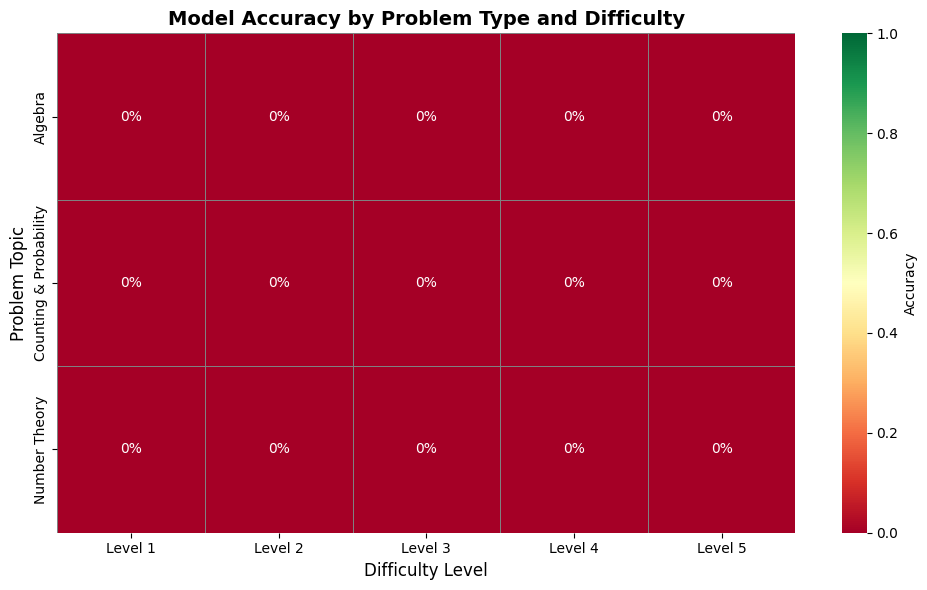


📊 Heatmap Data (Accuracy Matrix):
difficulty              Level 1  Level 2  Level 3  Level 4  Level 5
topic                                                              
Algebra                     0.0      0.0      0.0      0.0      0.0
Counting & Probability      0.0      0.0      0.0      0.0      0.0
Number Theory               0.0      0.0      0.0      0.0      0.0


In [ ]:
# Create pivot table for heatmap
heatmap_data = eval_df.groupby(['topic', 'difficulty'])['is_correct'].mean().unstack(fill_value=np.nan)

# Reorder columns by difficulty
difficulty_order = ['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5']
heatmap_data = heatmap_data.reindex(columns=[col for col in difficulty_order if col in heatmap_data.columns])

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0%',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Accuracy'},
    linewidths=0.5,
    linecolor='gray',
    mask=heatmap_data.isna()
)

plt.title('Model Accuracy by Problem Type and Difficulty', fontsize=14, fontweight='bold')
plt.xlabel('Difficulty Level', fontsize=12)
plt.ylabel('Problem Topic', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 Heatmap Data (Accuracy Matrix):")
print(heatmap_data)

## Additional Visualizations

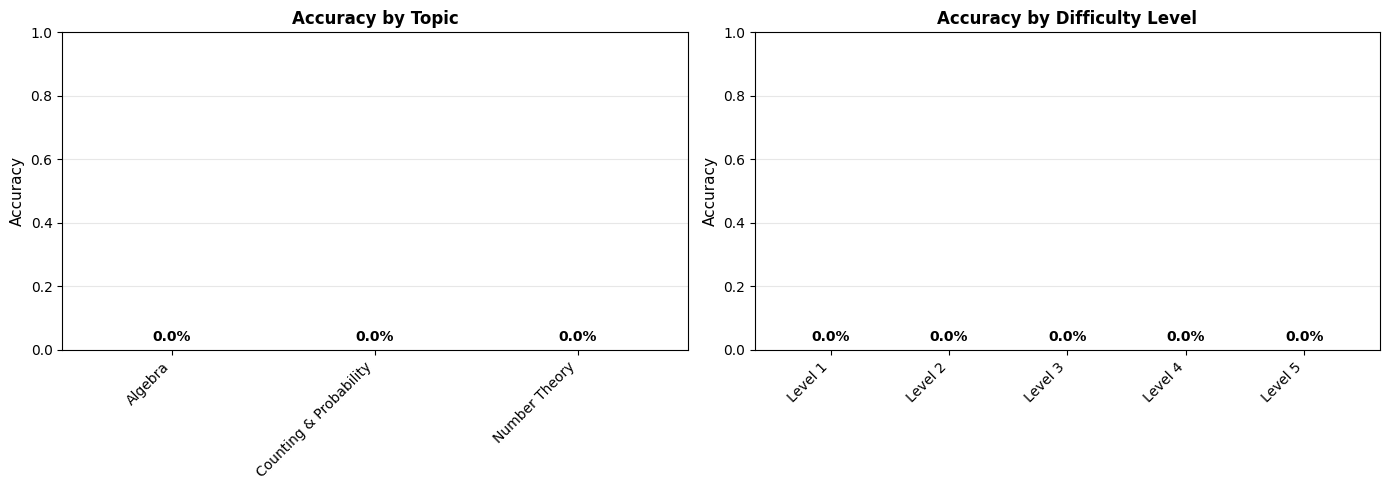

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Accuracy by Topic
topic_acc_values = eval_df.groupby('topic')['is_correct'].mean().sort_values(ascending=False)
axes[0].bar(range(len(topic_acc_values)), topic_acc_values.values, color='steelblue', alpha=0.7)
axes[0].set_xticks(range(len(topic_acc_values)))
axes[0].set_xticklabels(topic_acc_values.index, rotation=45, ha='right')
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Accuracy by Topic', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(topic_acc_values.values):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontweight='bold')

# Bar chart: Accuracy by Difficulty
diff_acc_values = eval_df.groupby('difficulty')['is_correct'].mean()
level_order = ['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5']
diff_acc_values = diff_acc_values.reindex([l for l in level_order if l in diff_acc_values.index])

axes[1].bar(range(len(diff_acc_values)), diff_acc_values.values, color='coral', alpha=0.7)
axes[1].set_xticks(range(len(diff_acc_values)))
axes[1].set_xticklabels(diff_acc_values.index, rotation=45, ha='right')
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Accuracy by Difficulty Level', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(diff_acc_values.values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Capture Hidden States (Sample)

Capture hidden states for a sample of problems to analyze later. This can help understand what the model is learning.

In [ ]:
# Sample problems for hidden state capture
# Try to get a diverse sample: some correct, some incorrect, across topics and difficulties
HIDDEN_STATE_SAMPLE_SIZE = 15

# Get stratified sample
correct_samples = eval_df[eval_df['is_correct'] == True].sample(min(len(eval_df[eval_df['is_correct'] == True]), HIDDEN_STATE_SAMPLE_SIZE // 2), random_state=42)
incorrect_samples = eval_df[eval_df['is_correct'] == False].sample(min(len(eval_df[eval_df['is_correct'] == False]), HIDDEN_STATE_SAMPLE_SIZE // 2), random_state=42)
hidden_state_samples = pd.concat([correct_samples, incorrect_samples]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Capturing hidden states for {len(hidden_state_samples)} problems...")
print(f"Distribution: {hidden_state_samples['is_correct'].value_counts().to_dict()}")

hidden_states_list = []
hidden_state_metadata = []

for idx, row in tqdm(hidden_state_samples.iterrows(), total=len(hidden_state_samples), desc="Capturing hidden states"):
    # Get hidden states by doing a forward pass on the question
    inputs = tokenizer(row['question'], return_tensors="pt")
    inputs = inputs.to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True, use_cache=False)
        hidden_states = outputs.hidden_states
        layer_hidden = [h.squeeze(0).detach().cpu().numpy() for h in hidden_states]
        layer_means = [h.mean(axis=0) for h in layer_hidden]

    hidden_states_list.append(layer_means)
    hidden_state_metadata.append({
        'id': row['id'],
        'topic': row['topic'],
        'difficulty': row['difficulty'],
        'is_correct': row['is_correct'],
        'question': row['question']
    })

# Convert to numpy array
hidden_states_array = np.array(hidden_states_list, dtype=np.float32)
print(f"\nHidden states shape: {hidden_states_array.shape}")
print(f"Format: (num_samples={hidden_states_array.shape[0]}, num_layers={hidden_states_array.shape[1]}, hidden_dim={hidden_states_array.shape[2]})")

# Save hidden states and metadata
np.savez_compressed(
    "performance_test_hidden_states.npz",
    hidden_states=hidden_states_array,
    metadata=np.array(hidden_state_metadata)
)

print("\n✅ Saved hidden states to 'performance_test_hidden_states.npz'")
print("   You can load this later for analysis with: np.load('performance_test_hidden_states.npz', allow_pickle=True)")

Capturing hidden states for 7 problems...
Distribution: {False: 7}


Capturing hidden states:   0%|          | 0/7 [00:00<?, ?it/s]


Hidden states shape: (7, 29, 3584)
Format: (num_samples=7, num_layers=29, hidden_dim=3584)

✅ Saved hidden states to 'performance_test_hidden_states.npz'
   You can load this later for analysis with: np.load('performance_test_hidden_states.npz', allow_pickle=True)


## Save Results

In [ ]:
# Save evaluation results
eval_df.to_csv('performance_test_results.csv', index=False)
print("✅ Saved evaluation results to 'performance_test_results.csv'")

# Save accuracy matrix
heatmap_data.to_csv('performance_test_accuracy_matrix.csv')
print("✅ Saved accuracy matrix to 'performance_test_accuracy_matrix.csv'")

# Summary statistics
print("\n" + "="*60)
print("EVALUATION SUMMARY")
print("="*60)
print(f"Total problems evaluated: {len(eval_df)}")
print(f"Overall accuracy: {eval_df['is_correct'].mean():.2%}")

topic_summary = eval_df.groupby('topic')['is_correct'].mean()
if len(topic_summary) > 0:
    print(f"\nBest performing topic: {topic_summary.idxmax()} ({topic_summary.max():.2%})")
    print(f"Worst performing topic: {topic_summary.idxmin()} ({topic_summary.min():.2%})")

diff_summary = eval_df.groupby('difficulty')['is_correct'].mean()
if len(diff_summary) > 0:
    print(f"\nBest performing difficulty: {diff_summary.idxmax()} ({diff_summary.max():.2%})")
    print(f"Worst performing difficulty: {diff_summary.idxmin()} ({diff_summary.min():.2%})")
print("="*60)

✅ Saved evaluation results to 'performance_test_results.csv'
✅ Saved accuracy matrix to 'performance_test_accuracy_matrix.csv'

EVALUATION SUMMARY
Total problems evaluated: 15
Overall accuracy: 0.00%

Best performing topic: Algebra (0.00%)
Worst performing topic: Algebra (0.00%)

Best performing difficulty: Level 1 (0.00%)
Worst performing difficulty: Level 1 (0.00%)


## Example: View Some Results

In [ ]:
# Show a few examples - some correct and some incorrect
print("Example correct answers:")
print("="*80)
for idx, row in eval_df[eval_df['is_correct'] == True].head(2).iterrows():
    print(f"\nProblem {row['id']} ({row['topic']}, {row['difficulty']})")
    print(f"Question: {row['question']}")
    print(f"Expected: {extract_boxed_answer(extract_model_answer(row))}")
    print(f"Model: {row['model_answer']}")
    print("-"*80)

print("\n\nExample incorrect answers:")
print("="*80)
for idx, row in eval_df[eval_df['is_correct'] == False].head(2).iterrows():
    print(f"\nProblem {row['id']} ({row['topic']}, {row['difficulty']})")
    print(f"Question: {row['question']}")
    print(f"Expected: {extract_boxed_answer(extract_model_answer(row))}")
    print(f"Model: {row['model_answer']}")
    print("-"*80)

Example correct answers:


Example incorrect answers:

Problem 2 (Algebra, Level 1)
Question: The perimeter of a rectangular garden is 60 feet. If the length of the field is twice the width, what is the area of the field, in square feet?
Expected: 200
Model: Solve the following math problem step by step. At the very end, output one final line of the form: Final: \boxed{your answer}.

The perimeter of a rectangular garden is 60 feet. If the length of the field is twice the width, what is the area of the field, in square feet?

Solution: 

First, let's define the variables. Let the width of the garden be \( w \) feet. Since the length is twice the width, the length will be \( 2w \) feet.

The perimeter of a rectangle is given by the formula:
\[
P = 2 \times (length + width)
\]
We know the perimeter is 60 feet, so:
\[
60 = 2 \times (2w + w)
\]
Simplify the equation:
\[
60 = 2 \times 3w
\]
\[
60 = 6w
\]
Divide both sides by 6:
\[
w = 10
\]
So, the width is 10 feet. The length is twice the 